# quick ecommerce analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [3]:
df=pd.read_csv("quick_commerce_data_raw.csv")
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [5]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [6]:
df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [7]:
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


In [8]:
df[df.isna().all(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating


In [9]:
df.dropna(subset=['City'],inplace=True)
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [10]:
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [11]:
x=df["Items_Count"].mode()
df['Items_Count'].fillna(x[0],inplace=True)
df

C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\4059332723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Items_Count'].fillna(x[0],inplace=True)


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [12]:
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [13]:
df['Customer_Rating']=df.groupby("Company")['Customer_Rating'].transform(lambda x:x.fillna(x.mean()))

In [14]:
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [15]:
df['Delivery_Partner_Rating']=df.groupby("Delivery_Time_Min")['Delivery_Partner_Rating'].transform(lambda x:x.fillna(x.mean()))

In [16]:
df.isnull().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [17]:
df['Delivery_Partner_Rating']=df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())

In [18]:
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

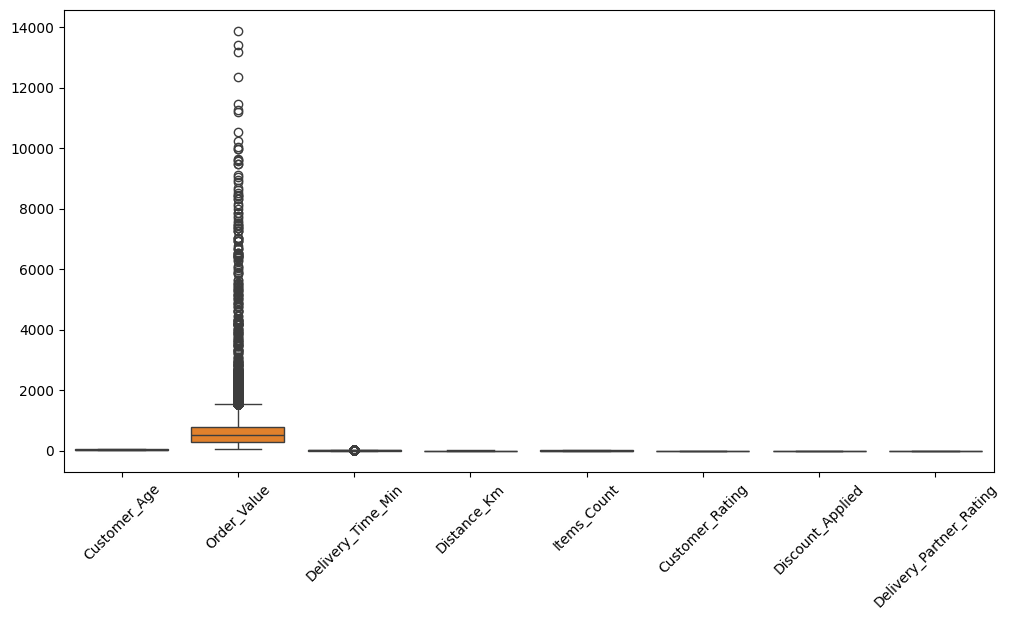

In [19]:
cols = [
    'Customer_Age',
    'Order_Value',
    'Delivery_Time_Min',
    'Distance_Km',
    'Items_Count',
    'Customer_Rating',
    'Discount_Applied',
    'Delivery_Partner_Rating'
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()


In [20]:
df = df[df['Order_Value'] <= 2500]


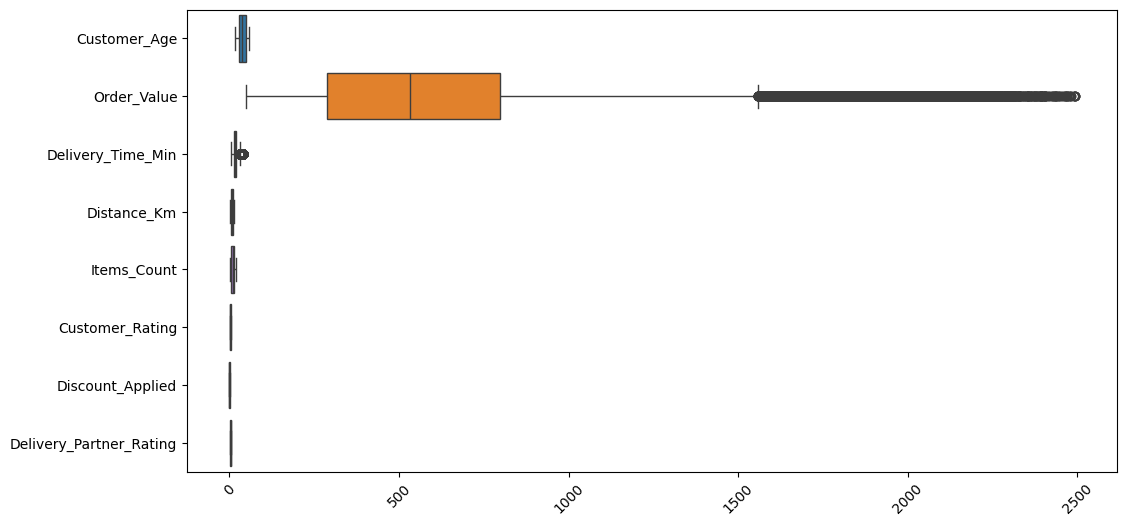

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols],orient='h')
plt.xticks(rotation=45)
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB


In [23]:
# changing the datatype

df['Order_ID']=df['Order_ID'].astype(str)
df.head()

C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3962215260.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_ID']=df['Order_ID'].astype(str)


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [24]:
df["Order_Value"]=np.round(df["Order_Value"])
df["Delivery_Time_Min"]=np.round(df["Delivery_Time_Min"])
df["Distance_Km"]=np.round(df["Distance_Km"],1)
df["Items_Count"]=np.round(df["Items_Count"])
df["Customer_Rating"]=np.round(df["Customer_Rating"])
df["Discount_Applied"]=np.round(df["Discount_Applied"])
df["Delivery_Partner_Rating"]=np.round(df["Delivery_Partner_Rating"])

df.head()

C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3537785939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order_Value"]=np.round(df["Order_Value"])
C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3537785939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Delivery_Time_Min"]=np.round(df["Delivery_Time_Min"])
C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3537785939.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.0,Household,Wallet,4.0,0,5.0


In [25]:
# df["Order_Value"]=np.round(df["Order_Value"])
# df["Delivery_Time_Min"]=np.round(df["Delivery_Time_Min"])
# df["Distance_Km"]=np.round(df["Distance_Km"],1)
# df["Items_Count"]=np.round(df["Items_Count"])
# df["Customer_Rating"]=np.round(df["Customer_Rating"])
# df["Discount_Applied"]=np.round(df["Discount_Applied"])
# df["Delivery_Partner_Rating"]=np.round(df["Delivery_Partner_Rating"])

df['Order_Value']=df['Order_Value'].astype('Int32')
df['Delivery_Time_Min']=df['Delivery_Time_Min'].astype('Int32')
df['Items_Count']=df['Items_Count'].astype('Int32')
df['Customer_Rating']=df['Customer_Rating'].astype('Int32')
df['Delivery_Partner_Rating']=df['Delivery_Partner_Rating'].astype('Int32')


df.info()

C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3378675048.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Value']=df['Order_Value'].astype('Int32')
C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3378675048.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Time_Min']=df['Delivery_Time_Min'].astype('Int32')
C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\3378675048.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  Int32  
 5   Delivery_Time_Min        947752 non-null  Int32  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  Int32  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  Int32  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  Int32  
dtypes: Int32(5), float64(1), int64(2), object(5)
memory usage: 87.7+

Q-1. which quick commerce platform has the highest total revenue?

In [30]:
Company_revenue=df.groupby('Company')['Order_Value'].sum().sort_values(ascending=False)

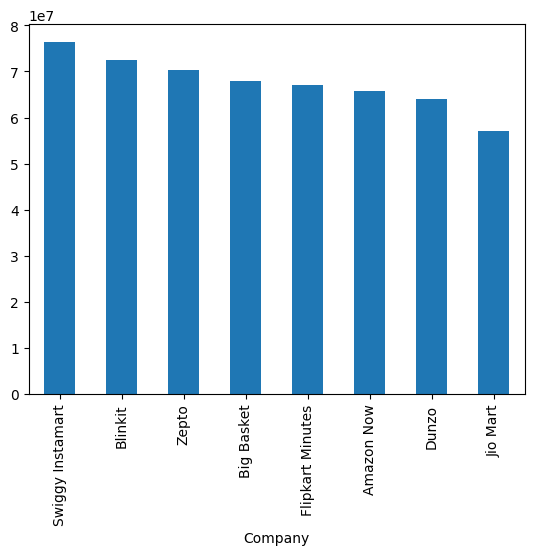

In [31]:
plt.Figure(figsize=(10,6))
Company_revenue.plot(kind="bar")
plt.show()


C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\2092450615.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data,x='Company',y='Order_Value',palette=colors,legend=False)


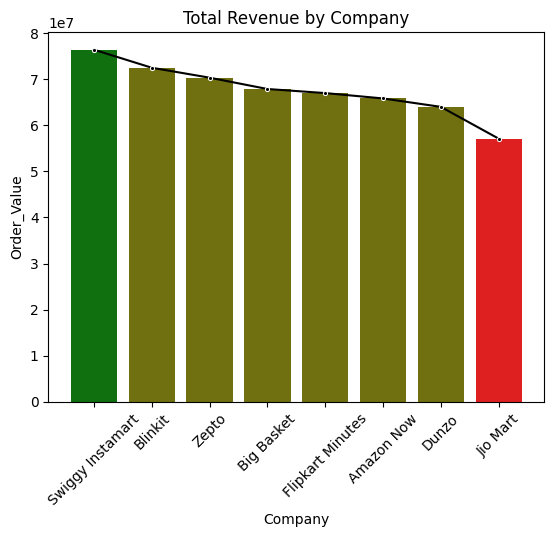

In [46]:
plot_data=Company_revenue.reset_index()
min_value=Company_revenue.min()
max_value=Company_revenue.max()
colors=[
        "green" if val==max_value 
        else 
        "red" 
        if val==min_value else 
        "olive"
        for val in Company_revenue
      ]
sns.barplot(data=plot_data,x='Company',y='Order_Value',palette=colors,legend=False)
sns.lineplot(data=plot_data,x='Company',y='Order_Value',color="black",marker=".")
plt.title("Total Revenue by Company")
plt.xticks(rotation=45)
plt.show()

Q-2. which platform has the highest average order value?


In [53]:
Aov=df.groupby('Company')['Order_Value'].mean().sort_values(ascending=False)
Aov

Company
Swiggy Instamart     644.92725
Blinkit             609.819198
Zepto               593.258314
Big Basket          575.065542
Flipkart Minutes    563.176472
Amazon Now          557.510429
Dunzo               540.317053
Jio Mart            482.914592
Name: Order_Value, dtype: Float64

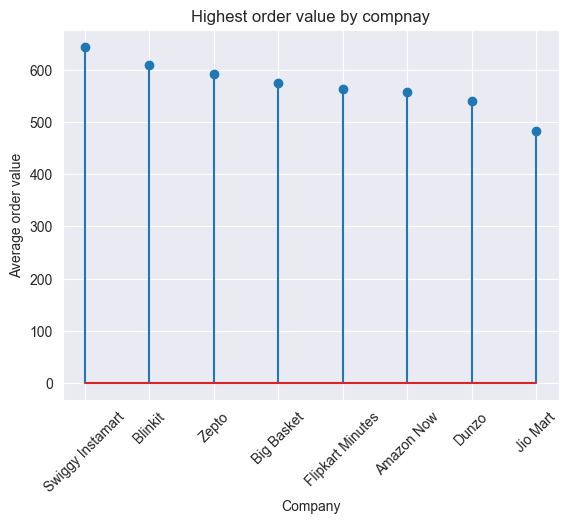

In [64]:
plt.Figure(figsize=(10,6))
plt.stem(Aov.index,Aov.values)
plt.title("Highest order value by compnay")
plt.xlabel("Company")
plt.ylabel("Average order value")
plt.xticks(rotation=45)
sns.set_style("dark")

plt.show()

Q-3 How does customer Rating vary across platforms?

In [68]:
cust_rating_per_company=df.groupby("Company")['Customer_Rating'].mean().sort_values(ascending=False)
cust_rating_per_company

Company
Blinkit             3.580762
Swiggy Instamart    3.279443
Zepto               3.203062
Big Basket          3.097902
Flipkart Minutes    3.016316
Amazon Now          2.913417
Jio Mart            2.819747
Dunzo               2.428024
Name: Customer_Rating, dtype: Float64

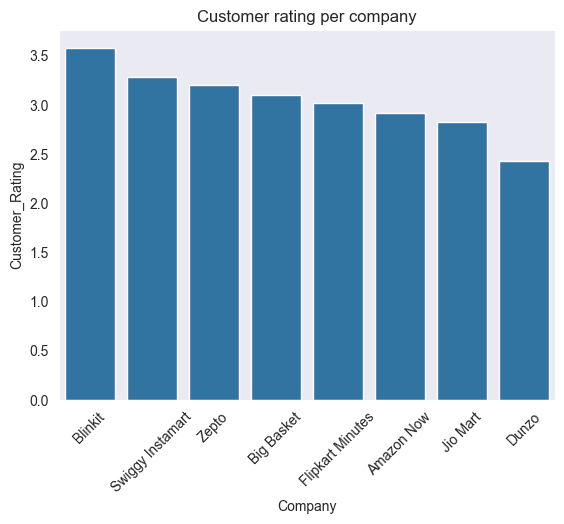

In [73]:
box_data=cust_rating_per_company.reset_index()
sns.barplot(data=box_data,x="Company",y="Customer_Rating")
plt.title("Customer rating per company")
plt.xticks(rotation=45)
plt.show()

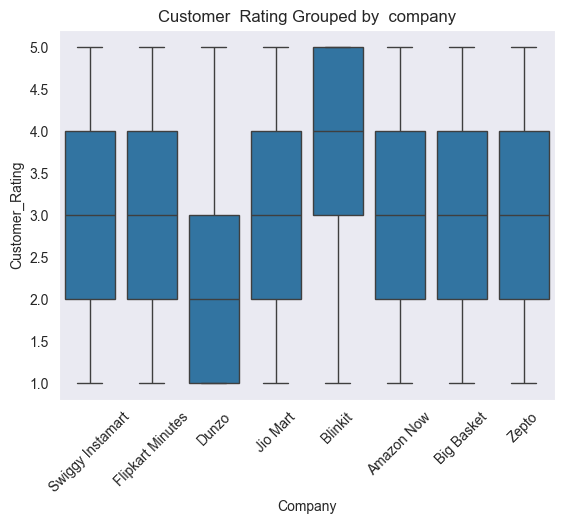

In [77]:
sns.boxplot(data=df,x="Company",y="Customer_Rating")
plt.title("Customer  Rating Grouped by  company")
plt.xticks(rotation=45)
plt.show()

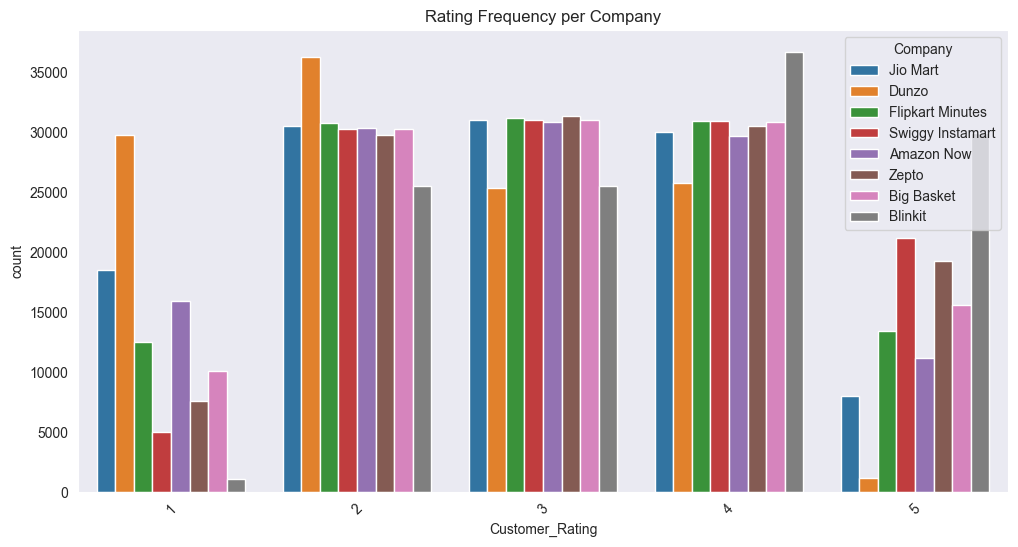

In [83]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Customer_Rating", hue="Company")

plt.title("Rating Frequency per Company")
plt.xticks(rotation=45)
plt.show()


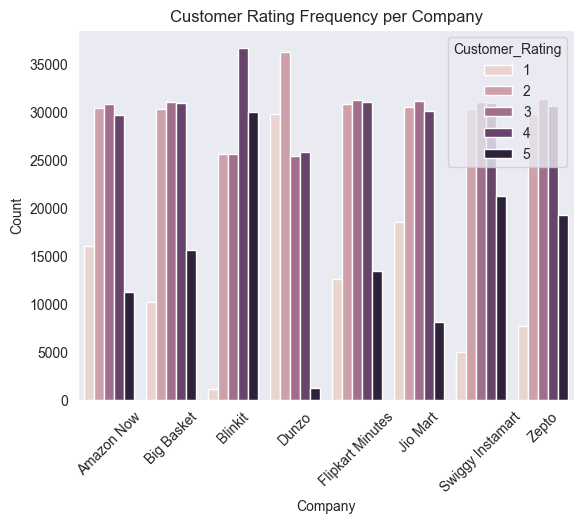

In [87]:
grouped_rating = df.groupby(["Company", "Customer_Rating"]).size().reset_index(name="Count")

sns.barplot(data=grouped_rating,
            x="Company",
            y="Count",
            hue="Customer_Rating")

plt.title("Customer Rating Frequency per Company")
plt.xticks(rotation=45)
plt.show()


Q-4. Does Delivery Time affects the Delivery partner Ratings?

In [88]:
df['Delivery_Time_Min'].mean()

np.float64(16.506619875241626)

In [89]:
df['Delivery_Partner_Rating'].mean()

np.float64(3.80029480285982)

In [103]:
x=df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()
x

Delivery_Time_Min
5     3.803956
6     3.798555
7     3.805901
8     3.803807
9     3.804469
10    3.801688
11    3.799953
12    3.798843
13    3.795841
14    3.797351
15    3.797958
16    3.799191
17    3.802405
18    3.801744
19    3.809601
20    3.804773
21    3.803036
22    3.804585
23    3.794215
24    3.791258
25    3.800221
26    3.795316
27    3.799794
28    3.796314
29    3.792997
30    3.788537
31     3.80761
32    3.789012
33    3.781402
34    3.770451
35    3.779251
36    3.752239
37    3.732039
38    3.741307
39    3.799097
40    3.737589
Name: Delivery_Partner_Rating, dtype: Float64

In [92]:
df['Delivery_Time_Min'].corr(df["Delivery_Partner_Rating"])

np.float64(-0.002777340802669752)

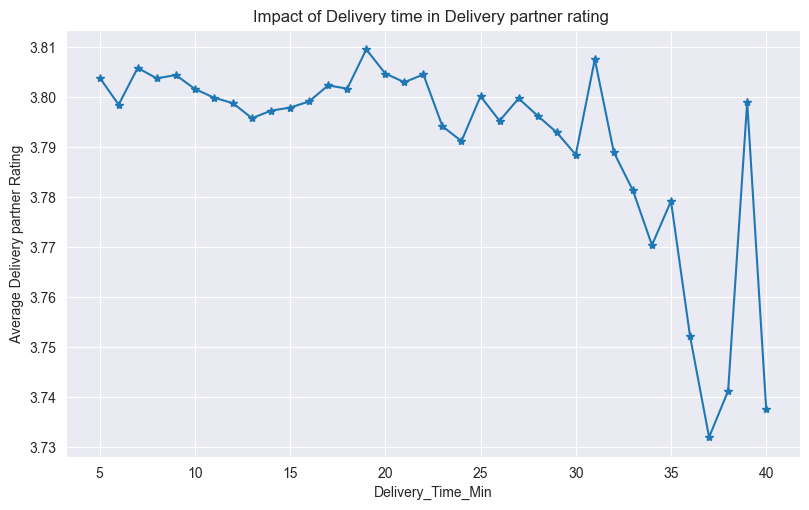

In [113]:
plt.figure(figsize=(8,5))

x.plot(marker="*")
plt.tight_layout()
plt.ylabel( " Average Delivery partner Rating ")
plt.title("Impact of Delivery time in Delivery partner rating ")
plt.grid()
plt.show()


In [115]:
df['Time_Bin'] = pd.cut(df['Delivery_Time_Min'],
                         bins=[0,10,20,30,40,50],
                         labels=["Very Fast Delivery"," Fast Delivery","normal Delivery","slow Delivery","Very slow Delivery"])
df


C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\748842347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_Bin'] = pd.cut(df['Delivery_Time_Min'],


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Time_Bin
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4,Fast Delivery
999997,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5,Fast Delivery
999998,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4,Fast Delivery


C:\Users\gandh\AppData\Local\Temp\ipykernel_11108\470465276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Time_Bin')['Delivery_Partner_Rating'].mean().plot(marker="*",color="purple")


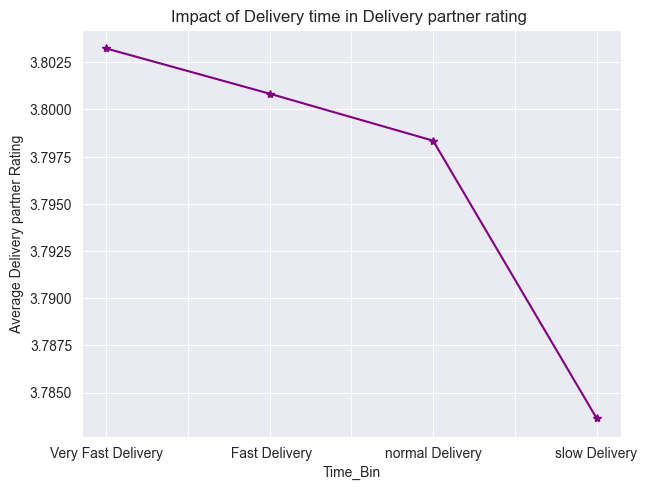

In [122]:
df.groupby('Time_Bin')['Delivery_Partner_Rating'].mean().plot(marker="*",color="purple")
plt.tight_layout()
plt.ylabel( " Average Delivery partner Rating ")
plt.title("Impact of Delivery time in Delivery partner rating ")
plt.grid()
plt.show()

Q-5 . what is the most popular product category on swiggy instamart,for popular of age between 30-40 ,in mumbai?

In [125]:
df_pc=df[((df['Company']=='Swiggy Instamart') &
(df['Customer_Age']>=30) & (df['Customer_Age']<=40) &
(df['City']=="Mumbai") )]
df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Time_Bin
536,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.7,18,Beverages,Cash on Delivery,4,1,4,Fast Delivery
909,1000910,Swiggy Instamart,Mumbai,32,926,20,14.2,3,Dairy,UPI,2,0,5,Fast Delivery
1203,1001204,Swiggy Instamart,Mumbai,37,234,19,7.6,6,Dairy,Debit Card,5,0,4,Fast Delivery
2918,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2,0,3,Fast Delivery
4251,1004252,Swiggy Instamart,Mumbai,36,50,15,2.2,12,Dairy,Credit Card,3,0,3,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998562,1998563,Swiggy Instamart,Mumbai,40,843,20,11.9,3,Personal Care,Cash on Delivery,4,0,4,Fast Delivery
999242,1999243,Swiggy Instamart,Mumbai,32,747,13,2.4,12,Household,UPI,5,1,5,Fast Delivery
999258,1999259,Swiggy Instamart,Mumbai,35,50,18,7.6,4,Personal Care,Debit Card,5,0,5,Fast Delivery
999680,1999681,Swiggy Instamart,Mumbai,39,375,19,8.7,6,Household,Wallet,2,0,4,Fast Delivery


In [126]:
df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  407
Groceries              384
Fruits & Vegetables    375
Snacks                 374
Household              372
Personal Care          343
Beverages              332
Name: count, dtype: int64

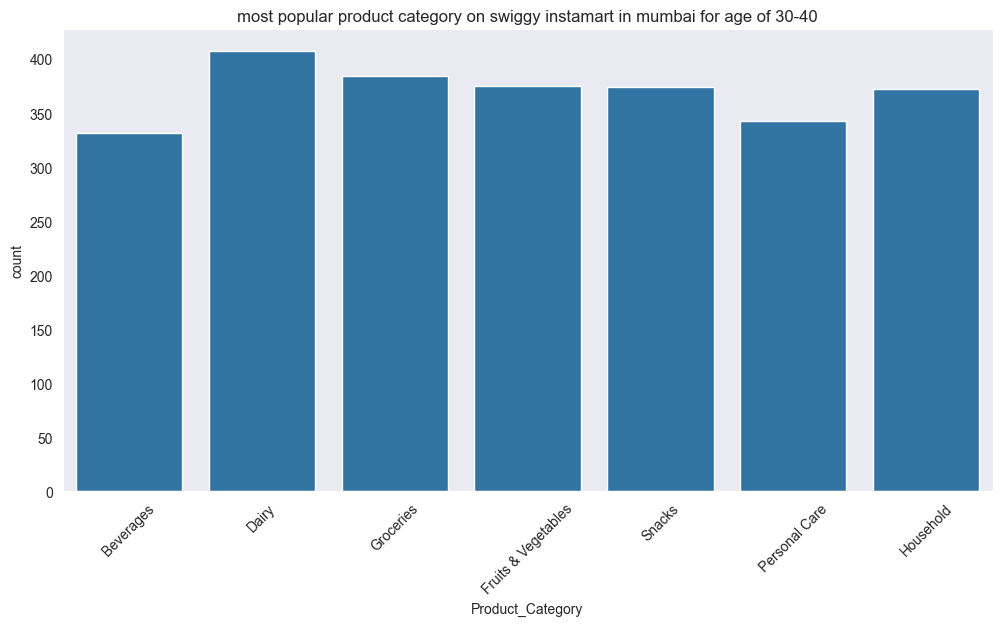

In [129]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_pc, x="Product_Category",)

plt.title("most popular product category on swiggy instamart in mumbai for age of 30-40")
plt.xticks(rotation=45)
plt.show()

Q-6 which cities should these compnay expands into based on performance?

In [130]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Time_Bin
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [136]:
city_pref=df.groupby(['Company','City']).agg(
  Total_orders=("Order_ID",'count'),
  Avg_Ratings=('Customer_Rating','mean'),
  Avg_Delivery_Time=('Delivery_Time_Min','mean'),
  Total_Revenue=('Order_Value','sum')
).reset_index()
city_pref

,Company,City,Total_orders,Avg_Ratings,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.896666,18.167388,5469439
1,Amazon Now,Bengluru,9905,3.387683,19.183342,5629936
2,Amazon Now,Chennai,9847,2.904032,18.138722,5363559
3,Amazon Now,Delhi,9918,2.989716,8.294616,5891026
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.112213,13.145278,4621428
92,Zepto,Kolkata,9825,3.173028,8.302901,5776955
93,Zepto,Mumbai,9861,3.41223,10.152013,6046485
94,Zepto,Noida,10070,3.206653,8.297617,7070769


In [137]:
best_cities=city_pref[
  (city_pref['Avg_Ratings']>=3.5) &
  (city_pref['Avg_Delivery_Time']<=15) &
  (city_pref['Total_orders']>city_pref['Total_orders'].median())
]
best_cities

,Company,City,Total_orders,Avg_Ratings,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
26,Blinkit,Chennai,9876,3.580903,14.135581,5921870
28,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
32,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
35,Blinkit,Pune,9908,3.583266,14.16411,5930415
85,Zepto,Bengluru,9971,3.598636,9.198977,6041668


<Axes: xlabel='City', ylabel='Total_Revenue'>

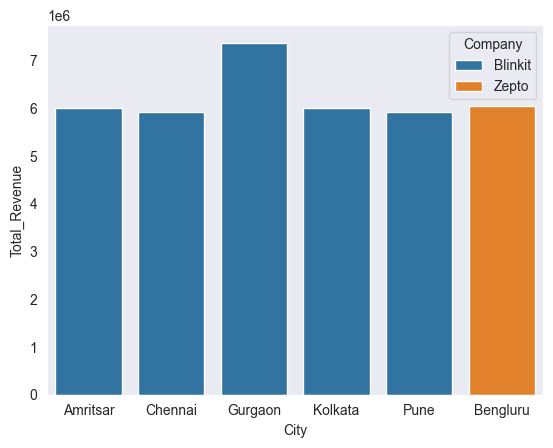

In [142]:
plt.Figure(figsize=(4,3))
sns.barplot(data=best_cities,x="City",y='Total_Revenue',hue='Company')

Q-7 Are discounts increasing order volume or just reducing revenue?

In [143]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Time_Bin
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [144]:
df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

<Axes: xlabel='Discount_Applied'>

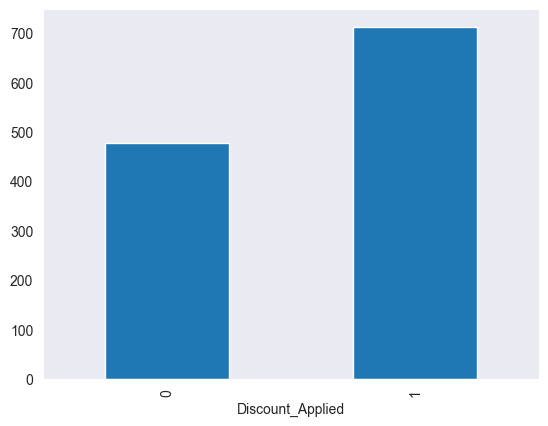

In [160]:
df.groupby("Discount_Applied")['Order_Value'].mean().plot(kind="bar")


<Axes: xlabel='Discount_Applied'>

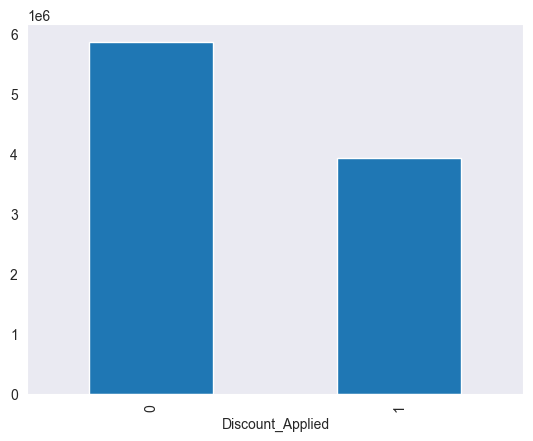

In [161]:
df.groupby("Discount_Applied")['Items_Count'].sum().plot(kind='bar')

Q-8) which company has the best operational Efficiency (Delivery time vs order volume)?


In [162]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Time_Bin
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [163]:
df.groupby("Company").agg(
                        Total_orders=('Order_ID','count'),
                        Average_Delivery_Time=('Delivery_Time_Min','mean')
                      
).reset_index()

,Company,Total_orders,Average_Delivery_Time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.17706
4,Flipkart Minutes,118965,17.04508
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.07269
7,Zepto,118565,9.644313


In [164]:
company_stats = df.groupby("Company").agg(
    Total_orders=('Order_ID','count'),
    Average_Delivery_Time=('Delivery_Time_Min','mean')
).reset_index()

# Min-Max Scaling
company_stats['Orders_scaled'] = (
    (company_stats['Total_orders'] - company_stats['Total_orders'].min()) /
    (company_stats['Total_orders'].max() - company_stats['Total_orders'].min())
)

company_stats['Delivery_Time_scaled'] = (
    (company_stats['Average_Delivery_Time'] - company_stats['Average_Delivery_Time'].min()) /
    (company_stats['Average_Delivery_Time'].max() - company_stats['Average_Delivery_Time'].min())
)

company_stats



,Company,Total_orders,Average_Delivery_Time,Orders_scaled,Delivery_Time_scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.17706,0.453159,0.339051
4,Flipkart Minutes,118965,17.04508,1.000000,0.55358
5,Jio Mart,118267,23.013224,0.239651,1.0
6,Swiggy Instamart,118475,16.07269,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.0


In [168]:
company_stats['Efficiency_Score']=company_stats['Orders_scaled']-company_stats['Delivery_Time_scaled']
company_stats

,Company,Total_orders,Average_Delivery_Time,Orders_scaled,Delivery_Time_scaled,Efficiency_Score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.17706,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.04508,1.000000,0.55358,0.44642
5,Jio Mart,118267,23.013224,0.239651,1.0,-0.760349
6,Swiggy Instamart,118475,16.07269,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.0,0.56427


In [170]:
eff=company_stats.sort_values(by='Efficiency_Score',ascending=False)
eff

,Company,Total_orders,Average_Delivery_Time,Orders_scaled,Delivery_Time_scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.0,0.56427
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.04508,1.000000,0.55358,0.44642
3,Dunzo,118463,14.17706,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.07269,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.0,-0.760349


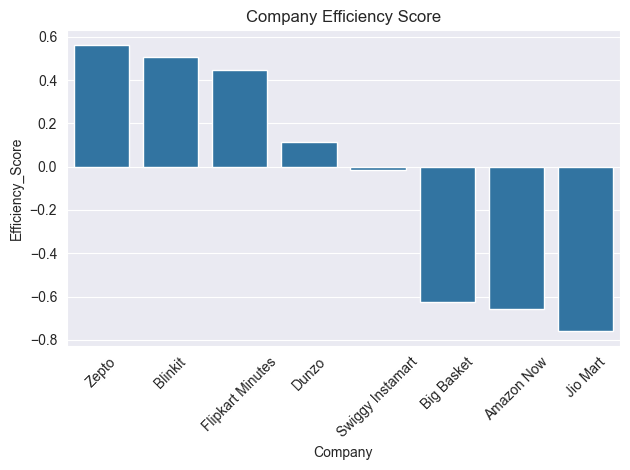

In [177]:
sns.barplot(data=eff,
            x="Company",
            y="Efficiency_Score")

plt.xticks(rotation=45)
plt.title("Company Efficiency Score")
plt.grid(axis='y')   # sirf horizontal grid
plt.tight_layout()
plt.show()

In [180]:
fig = px.scatter(
    eff,
    x="Average_Delivery_Time",
    y="Efficiency_Score",
    size="Total_orders",
    color="Company",
    hover_name="Company",
    size_max=60
)

fig.update_layout(
    title="Efficiency vs Delivery Time",
    xaxis_title="Average Delivery Time",
    yaxis_title="Efficiency Score"
)

fig.show()


In [181]:
# KPI Calculations
total_revenue = df['Order_Value'].sum()
total_orders = df['Order_ID'].count()
avg_order_value = df['Order_Value'].mean()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_customer_rating = df['Customer_Rating'].mean()

best_company = eff.iloc[0]['Company']


In [217]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 🔢 KPI Calculations
total_revenue = df['Order_Value'].sum()
total_orders = df['Order_ID'].count()
avg_rating = df['Customer_Rating'].mean()
best_company = eff.iloc[0]['Company']

# Create 3x2 Subplot Layout
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Revenue by Company",
        "Average Order Value",
        "Customer Ratings",
        "Operational Efficiency",
        "Average Delivery Time by Company",
        ""  # Empty space (optional)
    )
)

# 1️⃣ Revenue
rev = df.groupby('Company')['Order_Value'].sum().reset_index()
fig.add_trace(
    go.Bar(x=rev['Company'], y=rev['Order_Value']),
    row=1, col=1
)

# 2️⃣ AOV
aov = df.groupby('Company')['Order_Value'].mean().reset_index()
fig.add_trace(
    go.Bar(x=aov['Company'], y=aov['Order_Value']),
    row=1, col=2
)

# 3️⃣ Ratings
ratings = df.groupby('Company')['Customer_Rating'].mean().reset_index()
fig.add_trace(
    go.Bar(x=ratings['Company'], y=ratings['Customer_Rating']),
    row=2, col=1
)

# 4️⃣ Efficiency
fig.add_trace(
    go.Bar(x=eff['Company'], y=eff['Efficiency_Score']),
    row=2, col=2
)

# 5️⃣ Average Delivery Time
delivery = df.groupby('Company')['Delivery_Time_Min'].mean().reset_index()
fig.add_trace(
    go.Bar(x=delivery['Company'], y=delivery['Delivery_Time_Min']),
    row=3, col=1
)

# 🏷 KPI Cards (Top Section)
fig.add_annotation(
    text=f"<b>Total Revenue:</b> ₹{total_revenue:,.0f}",
    x=0.02, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)

fig.add_annotation(
    text=f"<b>Total Orders:</b> {total_orders:,}",
    x=0.28, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)

fig.add_annotation(
    text=f"<b>Avg Rating:</b> {avg_rating:.2f}",
    x=0.52, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)

fig.add_annotation(
    text=f"<b>Top Efficiency:</b> {best_company}",
    x=0.75, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)

# Layout Adjustments
fig.update_layout(
    height=1100,
    width=1200,
    title={
        'text': "📊 Quick Commerce Performance Dashboard",
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False,
    margin=dict(t=160)
)

fig.show()
